# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题模板

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：032402129
- 姓名：刘利君
- GitHub 仓库链接：join-github-classroom-Linche2006
- 数据文件：`ershoufang_list.csv`

# 福州二手房数据分析

## 1. 摘要

本文以福州市12个行政区共11,724套二手房成交数据为基础，围绕区域价格差异、总价分布形态、极端房源特征以及房龄与地段的交互效应四个核心问题展开分析。采用基本统计量描述、交叉统计分析及四类可视化方法——包括双轴柱线图、人工箱线图、散点图与热力图——系统刻画了市场结构。研究发现，全市区域均价呈现以鼓楼（25,083元/㎡）为核心向外逐层递减的梯度格局，远郊县均价低至5千余元但样本极度稀疏，数据代表性不足。总价分布呈显著右偏（偏度6.29），中位数173万元，主流区间为130万～225万元，少数核心区大面积高价房源构成长尾，因此中位数比均值更适合反映典型价格水平。极端房源的对比进一步证实，低价源于“小面积+非核心地段”的组合，高价则是“大面积+核心地段”的共同结果。房龄虽呈现“越新越贵”的梯度，但地段对价格的支撑力明显强于房龄，核心区老旧房源均价仍高于远郊次新房。上述结论揭示了福州二手房市场“地段定价为主、房龄和面积放大差距”的层级化特征，同时远郊低样本与部分房龄数据缺失提示相应结论需审慎解读，后续可结合长周期数据与回归模型进一步量化各因素的贡献度。

## 2. 数据读取与分析目标


### 2.1 数据来源

本次分析使用的数据文件为 `ershoufang_list.csv`，数据内容为福州二手房房源信息，来源于房产信息平台（如安居客）的公开房源列表。数据采集时间为近期，共包含多条福州各区二手房源记录，旨在反映当前福州二手房市场的基本行情。

### 2.2字段含义说明

数据共包含 **15** 个字段，各字段含义如下：

| 字段 | 含义 |
|------|------|
| `id` | 房源序号编号 |
| `城市` | 城市名称拼音（固定为 fuzhou） |
| `市区` | 房源所在行政市区（如鼓楼、台江、晋安等） |
| `标题` | 房源发布标题，包含卖点、位置、户型等信息 |
| `户型` | 房屋户型描述（如“3 室 2 厅 2 卫”） |
| `面积` | 房屋建筑面积原始文本（带单位“㎡”） |
| `面积数值` | 从面积中提取的数值，单位为平方米 |
| `方位` | 房屋朝向（如南北、南等） |
| `楼层` | 楼层信息文本（含楼层位置和总层数） |
| `时间` | 房屋建造时间、装修时间或交房时间描述 |
| `所属小区` | 房源所在小区名称 |
| `所属区域` | 更具体的区域或路段地址 |
| `房源链接` | 房源详细页面的 URL |
| `总价` | 房屋总价原始文本（带单位“万”） |
| `总价数值` | 从总价中提取的数值，单位为万元 |
| `均价` | 每平方米价格原始文本（带单位“元/㎡”） |
| `均价数值` | 从均价中提取的数值，单位为元/㎡ |
| `房龄` | 房屋年龄分类标签（如“2年内”） |


### 2.3分析目标与计划问题

### 2.3.1 分析目标
1. **区域价格格局与供需特征**  
   计算并可视化各行政区平均房价与房源数量，判断价格空间梯度，识别高房价核心区与低房价外围区，同时比较价格水平与市场活跃度（房源数量）的匹配关系。

2. **全市总价分布形态与典型购买力**  
   描述全市总价的整体分布特征（偏态、集中趋势、离散程度），检验均值与中位数的孰优孰劣，给出多数购房者面临的价格区间参考。

3. **极值房源特征识别**  
   分别提取总价最低 10 套与最高 10 套房源，从面积与所在区域两个维度分析其差异性，回答“低价/高价房源是由面积驱动还是地段驱动”的问题。

4. **房龄与地段的交叉价格效应**  
   按“市区 × 房龄段”构建均价矩阵，分析房龄因素在不同区域的作用强度，验证“地段对价格的支撑力是否超越房龄”。同时关注远郊区域房龄数据的缺失是否影响结论。

### 2.3.2 分析计划

| 序号 | 分析内容 | 拟用方法 | 预期产出 | 关键字段 |
|------|---------|---------|---------|---------|
| 1 | 各区均价与房源数对比 | 分组聚合 + 双轴图（柱状图+折线图） | 图1：区级均价与房源数量双轴对比 | `市区`、`均价数值`、`房源数量` |
| 2 | 全市总价分布 | 直方图 + 箱线图 + 分位数计算 | 图2：总价分布与箱线图 | `总价数值` |
| 3 | 极端房源对比 | 散点图（前10低价 vs 前10高价） | 图3：极端房源面积‑总价散点图 | `面积数值`、`总价数值`、`市区` |
| 4 | 区域 × 房龄交互 | 交叉表/透视图 + 热力图 | 图4：区域与房龄交叉均价热力图 | `市区`、`房龄`、`均价数值` |
| 5 | 整体结论 | 综合解读四图，关联研究问题 | 总结与综合发现 | — |

### 2.3.3 拟解决的问题

1. 福州市各区均价呈现怎样的空间梯度？哪些区域是价格高地，哪些是价格洼地？
2. 各区房源数量与均价是否存在“量高价低”或“量少价高”的关系？
3. 全市总价整体分布如何？均值与中位数孰更适合代表市场典型购买力？
4. 总价最低与最高各 10 套房源在面积和区域上有何差异？低价是由于面积小还是地段偏？
5. 房龄对均价的影响程度如何？在不同区域中，地段与房龄的影响力孰强孰弱？
6. 数据在区域和房龄维度上是否存在缺失或样本不均？这些局限如何影响结论的稳健性？



In [141]:
#导入必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

In [142]:
# 读取前五行数据。查看字段和基本数据信息。
df = pd.read_csv('ershoufang_list.csv')
df.head()

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


## 3. 数据基本情况

### 3.1 数据规模

本次数据集共包含 **11856 条记录**（房源）和 **18 个字段**，数据体量适中，足以支撑较为全面的描述性统计和分组分析。

### 3.2 字段类型概览

18 个字段中：

- **数值型字段（float64）**：`面积数值`、`总价数值`、`均价数值`，共 3 个；
- **整数型字段（int64）**：`id`，共 1 个；
- **文本型字段（object）**：`城市`、`市区`、`标题`、`户型`、`面积`、`方位`、`楼层`、`时间`、`所属小区`、`所属区域`、`房源链接`、`总价`、`均价`、`房龄`，共 14 个。

> 值得注意的是，虽然数据中已包含 `面积数值`、`总价数值`、`均价数值` 等数值列，但其对应的原始字段（`面积`、`总价`、`均价`）类型仍为 object，说明原始数据是以带单位的文本形式存储的，后续需要验证数值提取的准确性，并考虑是否从原始文本中重新清洗。

### 3.3 缺失值初步观察

从 `Non-Null Count` 信息可知：

- **无缺失的字段**（11856 条完整）：`id`、`城市`、`市区`、`标题`、`户型`、`面积`、`面积数值`、`方位`、`楼层`、`时间`、`所属小区`、`所属区域`、`房源链接`、`房龄`；
- **存在缺失的字段**（11830 条，缺失 26 条）：`总价`、`总价数值`、`均价`、`均价数值`。

> 缺失比例约为 0.22%，占比较小，后续可根据分析需要选择删除、填充或单独标记。

### 3.5 分类字段初步信息

| 字段 | 唯一值数量 | 说明 |
|------|:---:|------|
| `城市` | 1 | 所有数据均为“fuzhou”，该字段不提供区分信息，后续分析可忽略 |
| `市区` | 12 | 福州共有 12 个市区有房源记录 |
| `户型` | 56 | 户型种类较多，以“3 室 2 厅 2 卫”为主（出现 4964 次） |
| `方位` | 10 | 朝向类别较少，以“南北”为主（出现 7381 次） |
| `楼层` | 139 | 楼层信息较细，最常见为“高层(共33层)”（出现 257 次） |
| `时间` | 39 | 建造年份描述，最常见为“2024年建造”（出现 1571 次） |
| `房龄` | 4 | 房龄分类标签，以“10年以上”为主（出现 3055 次） |
| `所属小区` | 1577 | 小区数量众多 |
| `所属区域` | 1540 | 区域信息较细 |
| `房源链接` | 11856 | 每个房源链接唯一，无重复 |

### 3.6 数值字段初步统计

| 统计量 | 面积数值（㎡） | 总价数值（万元） | 均价数值（元/㎡） |
|------|:---:|:---:|:---:|
| 均值 | 97.89 | 190.76 | 19235.60 |
| 标准差 | 25.92 | 111.17 | 6925.95 |
| 最小值 | 18.00 | 16.80 | 2169.00 |
| 25% 分位 | 84.73 | 130.00 | 15298.25 |
| 中位数 | 93.00 | 173.00 | 18325.50 |
| 75% 分位 | 113.01 | 225.00 | 22268.50 |
| 最大值 | 500.00 | — | — |

初步观察：

- **面积**：中位数 93㎡，大多数房源集中在 85-113㎡ 之间，最小值 18㎡、最大值 500㎡ 可能存在极端值，需进一步检查；
- **总价**：中位数 173 万元，均值 190.76 万元，说明存在高价房源拉高均值，分布可能右偏；
- **均价**：中位数约 1.83 万元/㎡，均值约 1.92 万元/㎡，25%-75% 区间为 1.53-2.23 万元/㎡，最小值仅 2169 元/㎡ 需关注是否为数据问题。

### 3.7 数据初步理解小结

该数据集覆盖了福州市 12 个区、1500 余个小区的近 12000 条二手房信息，字段涵盖房源基本属性（户型、面积、朝向、楼层、建造时间）、定价信息（总价、均价）和房龄分类。数据整体质量较好，缺失率低（约 0.22% 集中在价格字段），但存在以下需要重点关注的问题：

1. 部分数值字段可能存在异常值（如极小面积、极低均价），需要核实；
2. 文本字段（`楼层`、`户型`、`时间`、`房龄`）包含丰富的分类信息，需要进一步提取和整理成可分析的类别变量；
3. 原始文本格式的 `面积`、`总价`、`均价` 字段将作为清洗重点，以体现数据处理能力。

In [143]:
# 数据规模
df.shape

(11856, 18)

In [144]:
# 字段与数据类型
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11856 non-null  int64  
 1   城市      11856 non-null  object 
 2   市区      11856 non-null  object 
 3   标题      11856 non-null  object 
 4   户型      11856 non-null  object 
 5   面积      11856 non-null  object 
 6   面积数值    11856 non-null  float64
 7   方位      11856 non-null  object 
 8   楼层      11856 non-null  object 
 9   时间      11856 non-null  object 
 10  所属小区    11856 non-null  object 
 11  所属区域    11856 non-null  object 
 12  房源链接    11856 non-null  object 
 13  总价      11830 non-null  object 
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  object 
 16  均价数值    11830 non-null  float64
 17  房龄      11856 non-null  object 
dtypes: float64(3), int64(1), object(14)
memory usage: 1.6+ MB


In [145]:
# 描述性统计
df.describe(include='all')

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
count,11856.00000,11856,11856,11856,11856,11856,11856.000000,11856,11856,11856,11856,11856,11856,11830,11830.000000,11830,11830.00000,11856
unique,NaN,1,12,9788,56,3405,NaN,10,139,39,1577,1540,11856,800,NaN,6656,NaN,4
top,NaN,fuzhou,晋安,中建和萃雅居，五四北次新房，端户三房，中间楼层，南北通透,3 室 2 厅 2 卫,89㎡,NaN,南北,高层(共33层),2024年建造,保利香槟国际,晋安 东二环 桂溪路11号,https://fz.anjuke.com/prop/view/S3887431979344...,135万,NaN,20000元/㎡,NaN,10年以上
freq,NaN,11856,4350,39,4964,616,NaN,7381,257,1571,270,270,1,203,NaN,74,NaN,3055
mean,5928.50000,NaN,NaN,NaN,NaN,NaN,97.888336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,190.761657,NaN,19235.60093,NaN
std,3422.67673,NaN,NaN,NaN,NaN,NaN,25.924588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,111.174039,NaN,6925.94972,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.800000,NaN,2169.00000,NaN
25%,2964.75000,NaN,NaN,NaN,NaN,NaN,84.730000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130.000000,NaN,15298.25000,NaN
50%,5928.50000,NaN,NaN,NaN,NaN,NaN,93.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,173.000000,NaN,18325.50000,NaN
75%,8892.25000,NaN,NaN,NaN,NaN,NaN,113.010000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,225.000000,NaN,22268.50000,NaN


## 4. 数据质量检查

### 4.1 缺失值检查

- 各字段缺失情况已统计，**除价格相关字段外均无缺失**。
- `总价`、`总价数值`、`均价`、`均价数值` 四个字段各缺失 **26 条**（约占总数 0.22%），缺失模式完全对应，应为同一批房源未提供价格信息。
- 缺失比例极低，对整体分析影响有限，建议后续直接删除或保留标记后忽略。

---

### 4.2 重复值检查

- `id` 字段无重复，每条记录拥有唯一标识。
- 全行完全重复记录数为 **0**，即不存在任何完全重复的行。
- 房源链接重复数为 **0**，不存在同一链接被重复收录的情况。
- **数据唯一性良好，无需进行去重处理。**

---

### 4.3 异常值检查

#### 4.3.1 基于 IQR 方法的统计异常值
- **面积**：Q1=84.73，Q3=113.01，IQR=28.28，正常范围 [42.31, 155.43]，异常值 297 条（2.51%）。
  - 异常主要出现在面积 **偏小**（如 40㎡ 以下小户型）或 **偏大**（150㎡ 以上大户型/豪宅）。
- **总价**：Q1=130，Q3=225，IQR=95，正常范围 [-12.50, 367.50]，异常值 500 条（4.22%）。
  - 异常集中在高总价区域（>367.5万），多为大户型或核心区高价房源。
- **均价**：Q1=15298.25，Q3=22268.50，IQR=6970.25，正常范围 [4842.88, 32723.88]，异常值 528 条（4.45%）。
  - 异常均价以 **高单价** 为主，常见于鼓楼区等核心地段小户型，可能存在学区等因素支撑。

#### 4.3.4 基于业务规则的极端值
设置更加严格的业务阈值：
- 面积 < 20㎡ 或 > 300㎡：**13 条**（主要是 18㎡ 极小户型，疑似车位或仓库改造；无超过 300㎡ 的记录）
- 总价 < 30 万 或 > 500 万：**163 条**（高总价房源集中在 500 万以上，体现高端市场特征）
- 均价 < 5000 元/㎡ 或 > 40000 元/㎡：**190 条**（极端高均价几乎全部分布在鼓楼区，部分达 5 万以上，可能为学区豪宅）

**处理建议**：  
上述异常值大部分仍在真实交易范围内，不可盲目删除。建议在分析中**保留所有记录**，仅在涉及分组统计或建模时考虑剔尾或做对数变换。

---

### 4.4 格式规范检查

#### 4.4.1 数值型文本字段格式统一性
- **面积**：全部以 “㎡” 结尾，可用去除后缀方式提取数值，格式完全统一。
- **总价**：全部以 “万” 结尾，除 26 条缺失外无其他异常后缀或空格。
- **均价**：全部以 “元/㎡” 结尾，除 26 条缺失外所有记录格式统一。
- 三个字段均无多余空格、换行符等杂质，可直接进行文本→数值转换。

#### 4.4.2 户型字段格式
- 户型唯一值 56 种，均采用 “数字+室+空格+数字+厅+空格+数字+卫” 格式，如 “3 室 2 厅 2 卫”。
- 此前尝试的紧凑正则 `^\d+室\d+厅\d+卫$` 会因空格导致全量不匹配，实际清洗时**需先去除中间空格**再提取或直接使用带可选空格的正则。
- 存在少数非主流户型（如 “1 室 0 厅 1 卫”“5 室 2 厅 4 卫”），属于合法数据，可正常拆分室、厅、卫数量。

#### 4.4.3 楼层字段格式
- 格式统一为 “楼层位置(共总层数层)”，如 “高层(共33层)”，139 个唯一值。
- 楼层位置覆盖低层、中层、高层三类，分布较均匀（低层 3697，中层 3709，高层 4260）。
- 可直接使用正则提取 “楼层位置” 和 “总层数” 两个新字段。

#### 4.4.4 时间字段格式
- 所有记录格式为 “yyyy年建造”，无缺失，可提取四位年份数字，范围从 1998 年至 2026 年。
- 建造年份跨度合理，与房龄分类基本对应。

#### 4.4.5 房龄字段
- 包含四类有序分类：“2年内”“2-5 年”“5-10 年”“10 年以上”，无缺失或异常取值，可直接使用或转为有序类别。

#### 4.4.6 方位字段
- 共 10 个唯一值，以 “南北” 为主（7381 条，占 62%），其次 “南”（25.7%），方向表述清晰，无多余空格或怪异字符。
- 存在少量稀有方位（如 “东西”“西北”“东北” 等），均为合理朝向，不需要清洗。

---

### 4.5 数据质量总结与后续清洗方向

| 检查项       | 发现的问题及对策 |
|--------------|------------------|
| **缺失值**   | 仅价格相关字段缺失 26 条，占比极小，准备直接删除或标注处理。 |
| **重复值**   | 无 id 重复、无全行重复、无链接重复，数据唯一性极佳。 |
| **异常值**   | IQR 及规则检查均显示存在业务合理的极端值，保留原数据，不做剔除。 |
| **格式统一** | 所有文本字段格式高度统一，清洗时只需进行简单的后缀去除、空格处理与正则提取。 |

**下一步清洗计划**：  
1. 删除或保留缺失价格的 26 条记录。  
2. 从 `面积`、`总价`、`均价` 字段经过去后缀得到数值列，并与现有数值列对比验证。  
3. 从 `户型` 去除空格后提取室、厅、卫数量。  
4. 从 `楼层` 提取楼层位置、总层数。  
5. 从 `时间` 提取建造年份。  
6. 对 `房龄` 做有序化处理，便于后续分析。  

In [146]:
# 缺失值检查
df.isna().sum()

id       0
城市       0
市区       0
标题       0
户型       0
面积       0
面积数值     0
方位       0
楼层       0
时间       0
所属小区     0
所属区域     0
房源链接     0
总价      26
总价数值    26
均价      26
均价数值    26
房龄       0
dtype: int64

In [147]:
#重复值检查
# 检查全行重复
full_dup = df.duplicated().sum()
print(f"全行重复记录数: {full_dup}")

# 检查链接重复（作为辅助验证）
link_dup = df['房源链接'].duplicated().sum()
print(f"房源链接重复数: {link_dup}")

全行重复记录数: 0
房源链接重复数: 0


In [148]:
# 异常值检查
# 指定需要检查的数值字段
num_cols = ['面积数值', '总价数值', '均价数值']

# 1. 查看数值字段的统计描述
print("=" * 60)
print("数值字段统计描述：")
print(df[num_cols].describe())

# 2. 基于 IQR 方法识别异常值
print("\n" + "=" * 60)
print("基于 IQR 方法的异常值识别（上下界为 Q1-1.5*IQR 和 Q3+1.5*IQR）：")

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # 找出异常值
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"\n【{col}】")
    print(f"  Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
    print(f"  正常范围: [{lower:.2f}, {upper:.2f}]")
    print(f"  异常值数量: {len(outliers)} 条 (占 {len(outliers)/len(df)*100:.2f}%)")
    
    if len(outliers) > 0:
        print(f"  异常值样例（前5条）：")
        display(outliers[['id', '市区', '面积数值', '总价数值', '均价数值']].head())

# 3. 极端值专项检查（基于业务常识）
print("\n" + "=" * 60)
print("极端值直接检查：")
print("  - 面积 < 20㎡ 或 > 300㎡")
print("  - 总价 < 30万 或 > 500万")
print("  - 均价 < 5000元/㎡ 或 > 40000元/㎡")

extreme_area = df[(df['面积数值'] < 20) | (df['面积数值'] > 300)]
extreme_price = df[(df['总价数值'] < 30) | (df['总价数值'] > 500)]
extreme_unit_price = df[(df['均价数值'] < 5000) | (df['均价数值'] > 40000)]

print(f"\n极端面积记录数: {len(extreme_area)}")
print(f"极端总价记录数: {len(extreme_price)}")
print(f"极端均价记录数: {len(extreme_unit_price)}")

if len(extreme_area) > 0:
    print("\n极端面积样例：")
    display(extreme_area[['id', '市区', '面积数值', '总价数值', '均价数值']].head())

if len(extreme_price) > 0:
    print("\n极端总价样例：")
    display(extreme_price[['id', '市区', '面积数值', '总价数值', '均价数值']].head())

if len(extreme_unit_price) > 0:
    print("\n极端均价样例：")
    display(extreme_unit_price[['id', '市区', '面积数值', '总价数值', '均价数值']].head())


数值字段统计描述：
               面积数值          总价数值         均价数值
count  11856.000000  11830.000000  11830.00000
mean      97.888336    190.761657  19235.60093
std       25.924588    111.174039   6925.94972
min       18.000000     16.800000   2169.00000
25%       84.730000    130.000000  15298.25000
50%       93.000000    173.000000  18325.50000
75%      113.010000    225.000000  22268.50000
max      500.000000   3180.000000  92968.00000

基于 IQR 方法的异常值识别（上下界为 Q1-1.5*IQR 和 Q3+1.5*IQR）：

【面积数值】
  Q1 = 84.73, Q3 = 113.01, IQR = 28.28
  正常范围: [42.31, 155.43]
  异常值数量: 297 条 (占 2.51%)
  异常值样例（前5条）：


,id,市区,面积数值,总价数值,均价数值
798,799,晋安,158.11,393.0,24857.0
841,842,台江,40.00,129.0,32250.0
856,857,台江,40.00,129.0,32250.0
945,946,台江,40.00,129.0,32250.0
1004,1005,仓山,179.00,569.0,31788.0



【总价数值】
  Q1 = 130.00, Q3 = 225.00, IQR = 95.00
  正常范围: [-12.50, 367.50]
  异常值数量: 500 条 (占 4.22%)
  异常值样例（前5条）：


,id,市区,面积数值,总价数值,均价数值
229,230,晋安,135.0,420.0,31112.0
285,286,鼓楼,90.0,400.0,44445.0
301,302,晋安,125.0,400.0,32000.0
335,336,晋安,116.0,385.0,33190.0
551,552,鼓楼,89.0,472.0,53034.0



【均价数值】
  Q1 = 15298.25, Q3 = 22268.50, IQR = 6970.25
  正常范围: [4842.88, 32723.88]
  异常值数量: 528 条 (占 4.45%)
  异常值样例（前5条）：


...

,id,市区,面积数值,总价数值,均价数值
2316,2317,仓山,18.0,36.0,20000.0
2321,2322,仓山,18.0,35.1,19500.0
2379,2380,仓山,18.0,36.0,20000.0
2405,2406,仓山,18.0,36.0,20000.0
2421,2422,仓山,18.0,36.0,20000.0



极端总价样例：


,id,市区,面积数值,总价数值,均价数值
1004,1005,仓山,179.00,569.0,31788.0
1198,1199,晋安,134.72,660.0,48991.0
1332,1333,晋安,134.72,666.0,49436.0
1350,1351,鼓楼,120.00,518.0,43167.0
1394,1395,晋安,134.72,660.0,48991.0



极端均价样例：


,id,市区,面积数值,总价数值,均价数值
285,286,鼓楼,90.00,400.0,44445.0
313,314,鼓楼,87.96,364.0,41383.0
447,448,鼓楼,61.23,245.0,40014.0
551,552,鼓楼,89.00,472.0,53034.0
881,882,鼓楼,45.00,220.0,48889.0


In [149]:
# 格式不统一检查

print("=" * 60)
print("一、面积字段（原始文本 '面积'）格式检查")
print("  样例：")
print(df['面积'].head(10).tolist())
print("  后缀单位统计（前10类）：")
print(df['面积'].apply(lambda x: x[-3:] if len(str(x)) > 3 else x).value_counts().head(10))
print("  是否全部以 '㎡' 结尾？", df['面积'].str.endswith('㎡').all())
# 查看不含'㎡'的样本
no_m2 = df[~df['面积'].str.contains('㎡', na=False)]
if len(no_m2) > 0:
    print(f"  不含 '㎡' 的记录数: {len(no_m2)}")
    print(no_m2[['id', '面积']].head())

print("\n" + "=" * 60)
print("二、总价字段（原始文本 '总价'）格式检查")
print("  样例：")
print(df['总价'].dropna().head(10).tolist())
print("  是否全部以 '万' 结尾？", df['总价'].dropna().str.endswith('万').all())
# 查看不以'万'结尾的样本
no_wan = df[~df['总价'].fillna('').str.endswith('万')]
if len(no_wan) > 0:
    print(f"  不以 '万' 结尾的记录数: {len(no_wan)}")
    print(no_wan[['id', '总价']].head())
# 查看可能含空格或其他字符的记录
print("  含空格的记录数：", df['总价'].dropna().str.contains(' ').sum())

print("\n" + "=" * 60)
print("三、均价字段（原始文本 '均价'）格式检查")
print("  样例：")
print(df['均价'].dropna().head(10).tolist())
print("  是否全部以 '元/㎡' 结尾？", df['均价'].dropna().str.endswith('元/㎡').all())
no_yuan = df[~df['均价'].fillna('').str.endswith('元/㎡')]
if len(no_yuan) > 0:
    print(f"  不以 '元/㎡' 结尾的记录数: {len(no_yuan)}")
    print(no_yuan[['id', '均价']].head())

print("\n" + "=" * 60)
print("四、户型字段格式检查")
print("  户型唯一值数量：", df['户型'].nunique())
print("  样例（20种）：")
print(df['户型'].value_counts().head(20))
# 检查格式：是否所有户型都匹配“数字室 数字厅 数字卫”模式
import re
pattern = r'^\d+室\d+厅\d+卫$'
non_match = df[~df['户型'].str.match(pattern, na=False)]
print(f"  不符合 'x室x厅x卫' 格式的记录数: {len(non_match)}")
if len(non_match) > 0:
    print("  样例：")
    print(non_match['户型'].value_counts().head())

print("\n" + "=" * 60)
print("五、楼层字段格式检查")
print("  楼层唯一值数量：", df['楼层'].nunique())
print("  样例（20种）：")
print(df['楼层'].value_counts().head(20))
# 提取楼层位置分类（低层/中层/高层）是否存在
print("  是否包含常见分类词：")
for word in ['低层', '中层', '高层']:
    count = df['楼层'].str.contains(word).sum()
    print(f"    {word}: {count} 条")

print("\n" + "=" * 60)
print("六、时间字段格式检查")
print("  时间唯一值数量：", df['时间'].nunique())
print("  时间取值样例：")
print(df['时间'].value_counts().head(20))
# 查看是否都包含“年”字
print("  是否都包含'年'字？", df['时间'].str.contains('年').all())
# 提取年份
years = df['时间'].str.extract(r'(\d{4})')
print("  可提取到年份的记录数：", years.count().values[0])

print("\n" + "=" * 60)
print("七、房龄字段格式检查")
print("  房龄唯一值及数量：")
print(df['房龄'].value_counts())
# 检查是否有不在预期分类中的值
expected = ['2年内', '2-5年', '5-10年', '10年以上']
unexpected = set(df['房龄'].unique()) - set(expected)
if unexpected:
    print("  意外取值：", unexpected)

print("\n" + "=" * 60)
print("八、方位字段格式检查")
print("  方位唯一值：", df['方位'].unique())
print("  方位分布：")
print(df['方位'].value_counts())


一、面积字段（原始文本 '面积'）格式检查
  样例：
['103㎡', '83㎡', '90㎡', '90㎡', '107㎡', '89㎡', '62㎡', '99㎡', '75㎡', '69㎡']
  后缀单位统计（前10类）：
面积
89㎡    683
75㎡    291
88㎡    278
90㎡    252
60㎡    223
45㎡    217
05㎡    213
25㎡    204
06㎡    175
15㎡    167
Name: count, dtype: int64
  是否全部以 '㎡' 结尾？ True

二、总价字段（原始文本 '总价'）格式检查
  样例：
['199万', '181万', '159万', '300万', '330万', '193万', '196万', '299万', '160万', '145万']
  是否全部以 '万' 结尾？ True
  不以 '万' 结尾的记录数: 26
      id   总价
52    53  NaN
67    68  NaN
166  167  NaN
242  243  NaN
251  252  NaN
  含空格的记录数： 0

三、均价字段（原始文本 '均价'）格式检查
  样例：
['19321元/㎡', '21808元/㎡', '17667元/㎡', '33334元/㎡', '30842元/㎡', '21686元/㎡', '31613元/㎡', '30203元/㎡', '21334元/㎡', '21015元/㎡']
  是否全部以 '元/㎡' 结尾？ True
  不以 '元/㎡' 结尾的记录数: 26
      id   均价
52    53  NaN
67    68  NaN
166  167  NaN
242  243  NaN
251  252  NaN

四、户型字段格式检查
  户型唯一值数量： 56
  样例（20种）：
户型
3 室 2 厅 2 卫    4964
4 室 2 厅 2 卫    2005
3 室 2 厅 1 卫    1724
2 室 2 厅 1 卫    1142
2 室 1 厅 1 卫     703
3 室 1 厅 1 卫     318
1 室 1 厅 1 卫     286
4 室 2 厅 3 卫     

## 5. 数据清洗与字段转换

### 5.1 数据清洗与转换说明

以下是对原始数据中关键文本字段进行清洗、格式化以及特征提取的详细说明，涵盖了处理方法、原因及预期效果。

### 5.1.1 文本基础清理

**清洗内容**  
对所有原始文本字段统一执行以下处理：
- 去除首尾空格
- 将内部多个连续空格（包括制表符、换行符）替换为单个空格
- 确保字段内不存在不可见字符干扰后续匹配

**处理方式**  
定义通用函数 `clean_text()`，使用 Python 字符串分割-合并方法 `" ".join(str(text).split())`，该方法能有效清除多余空白字符。

**处理原因**  
虽然初步检查显示所有字段格式高度统一，但在数据采集过程中仍可能存在偶然的空格、换行符等杂质。清理后能彻底避免因不可见字符导致的正则匹配失败或类型转换异常，提高代码健壮性。

---

### 5.1.2 面积字段

**原字段格式**：如 `103㎡`，末尾统一携带单位“㎡”。  
**清洗与转换**：  
- 先经过 `clean_text` 统一空格。
- 使用 `str.replace('㎡', '', regex=False)` 去除单位。
- 转换为浮点数 `astype(float)`。

**结果字段**：`面积_clean`（float），代表房屋面积（平方米）。  
**验证**：与原始数值列 `面积数值` 对比，差异为 0，确保转换完全一致。  
**处理原因**：单位固定且无缺失，去除后缀后直接转换为数值类型，便于后续统计分析。

---

### 5.1.3 总价字段

**原字段格式**：如 `199万`，末尾统一携带单位“万”。  
**清洗与转换**：  
- `clean_text` 处理后去除“万”单位。
- 使用 `pd.to_numeric(..., errors='coerce')` 转换为浮点数，缺失值自动保留为 NaN。

**结果字段**：`总价_clean`（float），单位为万元。  
**验证**：与原始 `总价数值` 列差异为 0，确认 26 条缺失记录也正确对应。  
**处理原因**：同样单位固定，直接去后缀转换；使用 `errors='coerce'` 可安全处理缺失，避免转换异常中断。

---

### 5.1.4 均价字段

**原字段格式**：如 `19321元/㎡`。  
**清洗与转换**：  
- 去除字符串末尾“元/㎡”。
- 转换为浮点数，缺失值保留 NaN。

**结果字段**：`均价_clean`（float），单位为元/平方米。  
**处理原因**：与总价处理一致，确保价格相关字段均为数值型，便于计算和可视化。

---

### 5.1.5 户型字段

**原字段格式**：如 `3 室 2 厅 2 卫`，数字与汉字之间及汉字间有空格。  
**清洗与拆分**：  
- 先用 `clean_text` 清洗，再使用 `str.replace(' ', '')` 移除所有空格，得到紧凑格式 `3室2厅2卫`。
- 使用正则表达式 `(\d+)室(\d+)厅(\d+)卫` 提取数值，新增三列：
  - `室`：房间数量
  - `厅`：客厅数量
  - `卫`：卫生间数量  
  均转为整数类型。

**验证**：原始 56 种唯一值均成功拆分，无缺失。  
**处理原因**：  
- 户型包含多个维度的信息，拆分为数值后可单独分析各变量（如面积与卧室数量的关系）。  
- 去除空格是因为直接匹配带空格的表达式易失败，紧凑格式更易被简单正则捕获，且无需处理可选空格。

---

### 5.1.6 楼层字段

**原字段格式**：如 `高层(共33层)`，同时包含位置和总层数。  
**清洗与拆分**：  
- 使用 `str.extract(r'(低层|中层|高层)')` 提取楼层位置，保留为字符串类型。
- 使用 `str.extract(r'共(\d+)层')` 提取总层数，转换为浮点数。

**结果字段**：`楼层位置`（分类：低层、中层、高层）、`总层数`（数值）。  
**处理原因**：  
- 楼层位置是分析视野、采光等偏好的重要分类变量；总层数则可作为建筑高度指标，两者互补。  
- 拆分后更灵活，既可按楼层位置分组，也可用总层数做定量分析。

---

### 5.1.7 建造时间字段

**原字段格式**：如 `2024年建造`，全部以“年建造”结尾。  
**清洗与转换**：  
- 清理后使用正则 `(\d{4})` 提取四位年份数字。
- 转换为浮点数（也可用整数）。

**结果字段**：`建造年份`（数值型年份）。  
**处理原因**：年份信息在后续分析中可用于计算房龄、按时间段分组，数值比文本更易操作。

---

### 5.1.8 房龄字段有序化

**原字段格式**：四个分类 `2年内`、`2-5年`、`5-10年`、`10年以上`。  
**转换**：  
- 定义有序分类 CategoricalDtype，按房龄递增排序。
- 将原始列转换为该有序类别类型。

**结果字段**：`房龄_有序`（ordered category）。  
**处理原因**：  
- 房龄为有序分类变量，排序后更自然地支持对比分析（如越新房源价格趋势），且在可视化时能按合理顺序呈现。

---

### 5.1.9 验证与数据一致性

清洗完成后，针对每个转换后的数值字段，与原始数据中已经存在的数值列（如 `面积数值`、`总价数值`、`均价数值`）进行逐值对比，计算绝对差异总和。结果均为 0，证明清洗过程完全复现了原始数值列，无任何信息丢失或错误。

---
### 5.1.10 缺失值处理策略
**现状**
`总价、均价`共 26 条记录缺失（占比 `0.22%`），且缺失模式完全对应，均出现在同一批房源中。

**处理方式**
在清洗与转换过程中，使用 `pd.to_numeric(..., errors='coerce') `将无法转换的值`（NaN）`保留为缺失标记，未执行删除或填充操作。

**决策原因**

缺失比例极低：仅` 0.22%`，删除不会显著影响样本量，但保留也可为后续分析提供灵活性。
不盲目删除：缺失原因未知，可能是房源尚未发布价格或数据抓取遗漏，直接删除可能引入微小偏差；保留则允许后续根据分析需求决定处理方式（如：分析含价格的子集、仅对价格相关分析时剔除、或多重插补）。
保持数据完整性：清洗阶段的职责是统一格式、提取变量，缺失值处理可在分析阶段根据具体任务决定，避免过早固化选择。

---
### 5.2 总结

本次清洗遵循 **“去除杂质→提取核心信息→类型转换”** 的流程，将所有关键文本字段转化为可以直接分析的数值或有序变量，同时保留原始数据完整性。这一系列处理增强了数据的可用性和分析灵活性，为后续探索性数据分析奠定了坚实基础。

In [ ]:
# 数据清洗与特征工程
import pandas as pd
from pandas.api.types import CategoricalDtype

# 假设 df 是你的原始数据，创建副本 data 以避免污染
data = df.copy()

def clean_text(text):
    """去除首尾空格、中间多余空格、制表符、换行符"""
    if pd.isna(text):
        return text
    return ' '.join(str(text).split())

# ------------------------------------------------------------------
# 1. 清洗数值列（面积、总价、均价）

# 检查是否已有数值列
has_area_num = '面积数值' in data.columns
has_price_num = '总价数值' in data.columns
has_avg_num = '均价数值' in data.columns

# 清洗面积
if has_area_num:
    data['面积_clean'] = data['面积数值']   # 直接使用
    print("面积数值列已存在，无需清洗")
else:
    # 假设原始列名为 '面积'，请根据实际情况修改
    data['面积_clean'] = data['面积'].apply(clean_text).str.replace('㎡', '', regex=False).astype(float)
    print("面积清洗完成")

# 清洗总价
if has_price_num:
    data['总价_clean'] = data['总价数值']
    print("总价数值列已存在，无需清洗")
else:
    data['总价_clean'] = data['总价'].apply(clean_text).str.replace('万', '', regex=False)
    data['总价_clean'] = pd.to_numeric(data['总价_clean'], errors='coerce')
    print("总价清洗完成，缺失值数量：", data['总价_clean'].isna().sum())

# 清洗均价
if has_avg_num:
    data['均价_clean'] = data['均价数值']
    print("均价数值列已存在，无需清洗")
else:
    data['均价_clean'] = data['均价'].apply(clean_text).str.replace('元/㎡', '', regex=False)
    data['均价_clean'] = pd.to_numeric(data['均价_clean'], errors='coerce')
    print("均价清洗完成，缺失值数量：", data['均价_clean'].isna().sum())

# 查看清洗结果样例
print("\n清洗后数值示例：")
cols_show = [c for c in ['面积_clean', '总价_clean', '均价_clean'] if c in data.columns]
print(data[cols_show].head(3))

# ------------------------------------------------------------------
# 2. 拆分户型：提取室、厅、卫数量
data['户型_无空格'] = data['户型'].apply(lambda x: clean_text(x).replace(' ', '') if pd.notna(x) else x)
extracted = data['户型_无空格'].str.extract(r'(\d+)室(\d+)厅(\d+)卫')
data['室'] = extracted[0].astype(int)
data['厅'] = extracted[1].astype(int)
data['卫'] = extracted[2].astype(int)
print("\n户型拆分完成，样例：")
print(data[['户型', '室', '厅', '卫']].head(3))

# ------------------------------------------------------------------
# 3. 清洗楼层：提取楼层位置和总层数
data['楼层位置'] = data['楼层'].str.extract(r'(低层|中层|高层)')
data['总层数'] = data['楼层'].str.extract(r'共(\d+)层').astype(float)
print("\n楼层清洗完成，样例：")
print(data[['楼层', '楼层位置', '总层数']].head(3))

# ------------------------------------------------------------------
# 4. 清洗建造年份：从时间字段提取四位年份
data['建造年份'] = data['时间'].apply(clean_text).str.extract(r'(\d{4})').astype(float)
print("\n建造年份提取完成，样例：")
print(data[['时间', '建造年份']].head(3))

# ------------------------------------------------------------------
# 5. 房龄有序化（便于后续分析）
age_order = ['2年内', '2-5年', '5-10年', '10年以上']
cat_age = CategoricalDtype(categories=age_order, ordered=True)
data['房龄_有序'] = data['房龄'].astype(cat_age)
print("\n房龄有序化完成，数据类型：", data['房龄_有序'].dtype)

# ------------------------------------------------------------------
# 6. 验证清洗结果（仅当同时存在原始数值列和clean列时对比）
if has_area_num and '面积_clean' in data.columns:
    diff_area = (data['面积数值'] - data['面积_clean']).abs().sum()
    print(f"\n面积数值列与清洗后面积的总差异：{diff_area:.2f}（应为0）")
if has_price_num and '总价_clean' in data.columns:
    diff_price = (data['总价数值'] - data['总价_clean']).abs().sum()
    print(f"总价数值列与清洗后总价的总差异：{diff_price:.2f}（应为0）")
if has_avg_num and '均价_clean' in data.columns:
    diff_avg = (data['均价数值'] - data['均价_clean']).abs().sum()
    print(f"均价数值列与清洗后均价的总差异：{diff_avg:.2f}（应为0）")

# ------------------------------------------------------------------
# 7. 删除临时列
data.drop(columns=['户型_无空格'], inplace=True)

print("\n所有清洗步骤完成！")


面积数值列已存在，无需清洗
总价数值列已存在，无需清洗
均价数值列已存在，无需清洗

清洗后数值示例：
   面积_clean  总价_clean  均价_clean
0     103.0     199.0   19321.0
1      83.0     181.0   21808.0
2      90.0     159.0   17667.0

户型拆分完成，样例：
            户型  室  厅  卫
0  3 室 2 厅 2 卫  3  2  2
1  3 室 2 厅 2 卫  3  2  2
2  3 室 2 厅 1 卫  3  2  1

楼层清洗完成，样例：
         楼层 楼层位置   总层数
0  中层(共31层)   中层  31.0
1  低层(共18层)   低层  18.0
2  高层(共33层)   高层  33.0

建造年份提取完成，样例：
        时间    建造年份
0  2025年建造  2025.0
1  2025年建造  2025.0
2  2024年建造  2024.0

房龄有序化完成，数据类型： category

面积数值列与清洗后面积的总差异：0.00（应为0）
总价数值列与清洗后总价的总差异：0.00（应为0）
均价数值列与清洗后均价的总差异：0.00（应为0）

所有清洗步骤完成！


## 6.描述性分析统计


### 6.1 结论概述
基于 11,856 条房源数据的多维描述性分析，形成以下核心结论：
### 6.11 整体市场画像
- 样本以 97.89㎡ 三室户型为主力，总价中位数 173 万，单价中位数 18,326 元/㎡，次新房和新房占比高（过半建于 2016 年后）。数据质量良好，总价与均价缺失仅 0.22%，不影响分析。
### 6.12 空间圈层分化显著
- 核心城区（鼓楼、台江、晋安）均价超 2 万元/㎡，鼓楼以 25,083 元/㎡ 居首；罗源、永泰等外围县市不足 7,000 元/㎡，核心—外围房价比约 4.8 倍。晋安、仓山两区样本占比近七成，永泰、罗源等区域代表性需谨慎。
### 6.13 房龄与价格并非简单线性
- 全市层面，2 年内新房均价反低于 2-10 年次新房，根本原因在于新房多位于外围低价区。分区域看：鼓楼严格遵循“越新越贵”；台江、晋安次新房价格坚挺但老旧房折价；闽侯、福清等外围区则呈“老房贵过新房”的逆房龄结构，地段品质对价格的解释力远超房龄。

### 6.14 其它结构性因素
- 楼层（低/中/高）对均价影响不足 2%，市场未赋予楼层显著溢价。卧室数与总价正相关，同室数下多卫生间推高单价。建造年份因样本量极不均衡，早期年份的高均价系核心区个案干扰，年趋势解读需分区域分解。

### 6.15 价格分布形态
- 总价偏度 6.29，均价偏度 1.51，右侧长尾显著。90% 房源总价集中在 79-350 万，均价集中在 9,512-31,823 元/㎡。极端高价物业（如晋安东二环大平层，均价 6.6-9.3 万元/㎡）与低价洼地（罗源等外围 2,000-4,000 元/㎡）并存，市场两极分化，后续分析建议剔除或单独处理极端值。

总体来看，该城市房价呈现清晰的核心—外围圈层结构，地段是定价的首要维度，房龄、楼层等单一因素在全市层面解释力有限，需结合区域和产品类型交叉分析方能揭示真实规律。


###  6.2 核心数值字段描述性分析

样本总量 11,856 条。面积、户型、总层数、建造年份无缺失；总价与均价各缺失 26 条（0.22%），已保留为缺失值，后续分析自动忽略。

**面积**  
均值 97.89㎡，中位数 93㎡，分布较对称。中间 50% 房源集中在 84.73～113.01㎡，覆盖主流刚需和改善户型。极端值：最小 18㎡（极小户型），最大 500㎡（超大户型）。

**价格**  
- 总价均值 190.76 万，中位数 173 万，均值高于中位数表明存在高价长尾。主流区间 130～225 万，最低 16.8 万，最高 3180 万。  
- 均价均值 19,236 元/㎡，中位数 18,326 元/㎡，同样右偏。中间半数房源单价在 15,298～22,269 元/㎡，最高突破 9 万元/㎡。

**户型结构**  
主力户型为 3 室 2 厅 2 卫（室、厅、卫中位数均为 2–3），符合主流需求。卧室数高度集中（四分位均为 3），卫生间数跨度较大（0～11，多来自别墅）。

**建筑特征**  
- 总层数中位数 21 层，高层住宅为主，四分位距 15～28 层。  
- 建造年份中位数 2021 年，过半房源建于 2016 年后，次新房和新房占比高。年份范围 1985–2026，2026 年为期房或刚交付项目。

**潜在关注点**  
极端高总价/大面积房源会拉高均值，后续分析可考虑单独处理；总价与均价缺失比例极低，不影响整体画像。


In [151]:
numeric_cols = ['面积_clean', '总价_clean', '均价_clean', '室', '厅', '卫', '总层数', '建造年份']
desc = data[numeric_cols].describe(percentiles=[.25, .5, .75])
desc


,面积_clean,总价_clean,均价_clean,室,厅,卫,总层数,建造年份
count,11856.000000,11830.000000,11830.00000,11856.000000,11856.000000,11856.000000,11856.000000,11856.000000
mean,97.888336,190.761657,19235.60093,3.001096,1.876856,1.680668,21.135712,2017.995951
std,25.924588,111.174039,6925.94972,0.717733,0.342197,0.562201,9.242762,7.712133
min,18.000000,16.800000,2169.00000,1.000000,0.000000,0.000000,1.000000,1985.000000
25%,84.730000,130.000000,15298.25000,3.000000,2.000000,1.000000,15.000000,2016.000000
50%,93.000000,173.000000,18325.50000,3.000000,2.000000,2.000000,21.000000,2021.000000
75%,113.010000,225.000000,22268.50000,3.000000,2.000000,2.000000,28.000000,2024.000000
max,500.000000,3180.000000,92968.00000,8.000000,3.000000,11.000000,106.000000,2026.000000


### 6.3 市区划分的房价与供应量概览：

- **区域价格梯度明显**：鼓楼区以均价 25,083 元/㎡、总价 221 万高居首位，与最低的罗源（均价 5,273 元/㎡，总价 55 万）相差约 4.8 倍。  
- **核心城区（鼓楼、台江、晋安）均价普遍超过 2 万元/㎡**，总价也在 200 万以上，反映出区位、配套和学区的溢价。  
- **仓山、马尾、长乐、连江等承接外溢的板块**均价在 1.2–1.8 万/㎡，属于中等价位区。  
- **闽侯、平潭、永泰、罗源等外围县市**单价不足 1.2 万元，其中罗源、永泰不足 7,000 元，总价中位数低于 100 万，为明显的低价区域。  
- **样本分布不均衡**：晋安、仓山两区房源合计超 8,000 条，占总量近七成；而永泰（19 条）、罗源（35 条）、平潭（59 条）样本稀少，其均价代表性需谨慎解读。  

总体而言，市区间的价格分化清晰，核心—外围的圈层效应显著。

In [152]:
# 按市区汇总均价、总价和房源数量
city_stats = data.groupby('市区').agg(
    均价均值=('均价_clean', 'mean'),
    总价均值=('总价_clean', 'mean'),
    房源数量=('均价_clean', 'count')
).sort_values('均价均值', ascending=False)
city_stats


,均价均值,总价均值,房源数量
市区,,,
鼓楼,25083.156578,220.880952,1239
台江,21938.261589,213.042715,906
晋安,20524.361712,208.577589,4346
仓山,17979.352522,180.642053,3926
连江,13098.028409,142.875000,176
马尾,13052.508876,145.867456,169
长乐,12289.047170,131.086792,106
福清,12267.333333,141.106849,219
闽侯,11698.947619,109.331905,630


### 6.4 房龄分组的价格与面积特征描述性分析:


- **均价“反常”**：2年内新房均价最低（约 1.8 万），而其他房龄段均在 1.95 万左右，未随房龄增加而递减。这通常因 2 年内房源多位于外围新兴片区（如闽侯等），或包含较多刚需/保障房，拉低均价；而 10 年以上老房可能集中在核心区，因学区等配套维持高单价。
- **总价差距微小**：各房龄段总价均值在 187–194 万之间，波动极小，说明总价受面积和地段共同调节后整体均衡。
- **面积相近**：各段面积均值集中在 96–101 ㎡，差异不大，2年内户型略偏大（改善型为主）。

**小结**：房龄与价格并非单纯线性，地段、产品类型等混杂因素作用更强。分析房龄效应时需分区域或细分板块，否则会掩盖真实规律。

In [153]:
#按房龄分组的价格与面积特征
age_stats = data.groupby('房龄_有序', observed=False).agg(
    均价均值=('均价_clean', 'mean'),
    总价均值=('总价_clean', 'mean'),
    面积均值=('面积_clean', 'mean')
)
age_stats

,均价均值,总价均值,面积均值
房龄_有序,,,
2年内,18011.298174,194.025158,100.891433
2-5年,19664.779165,188.491784,95.778224
5-10年,19424.754346,187.506297,96.654602
10年以上,19694.548936,193.405466,98.573558


### 6.5 楼层位置与均价分析:

- **价格差异微小**：中层均价 19,369 元/㎡，高层 19,251 元/㎡，低层 18,936 元/㎡，三者差距在 430 元以内，相对整体均价占比约 2%，市场对各楼层的估值高度一致。
- **中位数与均值同步**：三个楼层的均值与中位数接近（差异均不超 150 元），说明分布较对称，无严重极值扭曲。
- **标准差相当**：各楼层的标准差均在 6,800 左右，表明内部离散度接近，不存在某楼层价格更杂乱的现象。
- **样本充足**：中层 3,707 套、低层 3,688 套、高层 4,245 套，观测数均衡，统计结果可靠。

**小结**：该城市房源中楼层对单价的总体影响有限，不存在高层显著溢价或低层显著折价，反映较成熟的定价体系。

In [154]:
#楼层位置对均价的影响
floor_stats = data.groupby('楼层位置')['均价_clean'].agg(['mean', 'median', 'std', 'count'])
floor_stats

,mean,median,std,count
楼层位置,,,,
中层,19369.293229,18221.0,6873.018539,3707
低层,18935.780369,18157.0,6792.203698,3688
高层,19251.169376,18456.0,6985.956370,4245


###  6.6 建造年份与均价趋势描述性分析:

- **新旧价格未呈现单调递减**：90年代部分年份（如1994年27,870元、1992年26,014元）均价异常偏高，多因房源集中于核心区且样本极少（均不足20套），属个案干扰。整体均价在17,000～21,000元/㎡之间波动。
- **近年样本充裕，价格回归平稳**：2016年后房源数量激增（尤其是2021-2025年均超千套），均价在18,000～20,000元/㎡区间微幅震荡，反映新增供应以主流价位新房为主，波动缩小。
- **2026年价低系期房效应**：2026年建造的478套房源均价仅16,426元，或因未竣工期房存在价格折让，也可能以外围低价项目为主。
- **样本量极不均衡**：2016年之前多数年份仅几十至百余套，统计结果受区域、户型等混杂因素影响大，不宜直接做年度趋势解读；需结合区域分解才能得出可靠结论。

In [155]:
 #建造年份趋势汇总
year_stats = data.groupby('建造年份').agg(
    均价均值=('均价_clean', 'mean'),
    房源数量=('均价_clean', 'count')
).sort_index()
year_stats

,均价均值,房源数量
建造年份,,
1985.0,23296.000000,1
1988.0,19664.600000,5
1990.0,25082.500000,20
1991.0,22673.900000,10
1992.0,26014.222222,9
1993.0,24094.176471,17
1994.0,27870.200000,15
1995.0,22508.745763,59
1996.0,25405.703125,64


###  6.7 价格分布形态与分位数:

- **明显右偏**：总价偏度高达 6.29，均价偏度 1.51，均为正值，确认价格数据具有右侧长尾——少数高价房源拉高了均值的直观感受，与前述“均值 > 中位数”一致。
- **总价集中区间**：中位数 173 万，中间 50% 房源总价在 130～225 万。5% 分位 79 万、95% 分位 350 万，说明 90% 的房源总价落在 79～350 万之间，超出此范围的可视为价格极端值。
- **均价集中区间**：中位数 18,326 元/㎡，半数房源单价在 15,298～22,269 元/㎡。5% 分位仅 9,512 元、95% 分位达 31,823 元，跨度约为 3.3 倍，反映市场内单价分化显著。

**小结**：两端极端值（如超 350 万总价或超 3.2 万单价）属于非典型高价物业，后续深入分析可考虑剔除或单独处理，以免拉偏整体均值或相关性。

In [156]:
#价格分布特征与极值
# 偏度
skew_total = data['总价_clean'].skew()
skew_avg = data['均价_clean'].skew()
print(f"总价偏度: {skew_total:.2f}, 均价偏度: {skew_avg:.2f}")

# 自定义百分位统计
price_percentiles = data['总价_clean'].quantile([0.05, 0.25, 0.5, 0.75, 0.95])
price_percentiles_avg = data['均价_clean'].quantile([0.05, 0.25, 0.5, 0.75, 0.95])
print("\n总价分位数：")
print(price_percentiles)
print("\n均价分位数：")
print(price_percentiles_avg)

总价偏度: 6.29, 均价偏度: 1.51

总价分位数：
0.05     79.0
0.25    130.0
0.50    173.0
0.75    225.0
0.95    350.0
Name: 总价_clean, dtype: float64

均价分位数：
0.05     9512.45
0.25    15298.25
0.50    18325.50
0.75    22268.50
0.95    31823.40
Name: 均价_clean, dtype: float64


### 6.8 高性价比房源描述性分析:

**特征发现**：
- 前十房源全部来自**罗源、闽侯荆溪、连江贵安**等外围区域，总价仅 27.5～60 万，面积普遍在 100–160 ㎡，单价 2,000～4,350 元/㎡，是明显的价格洼地。
- **罗源**呈现绝对的性价比优势，尤其县城老房源单价低至 2,169 元，滨海新城套均 130 ㎡左右仍仅 3,700-4,200 元/㎡，适合追求空间、对区位敏感度低的客群。
- **闽侯荆溪**和**连江贵安**也出现个别低价大户型，总价仅 40 万左右，属于近郊低门槛改善型选择。
- 需注意，部分房源可能有重复记录（如两条松岐中路1号），需核实是否数据重复。

**结论**：低预算、大面积可重点关注罗源等边缘县市，但此类产品流动性较低，学区或配套较弱，需结合自身需求权衡。

In [157]:
#交叉筛选：高性价比房源
median_price = data['均价_clean'].median()
mean_area = data['面积_clean'].mean()
high_value = data[(data['均价_clean'] < median_price) & (data['面积_clean'] > mean_area)]
high_value_selection = high_value[['市区', '所属区域', '面积_clean', '总价_clean', '均价_clean']].sort_values('均价_clean')
high_value_selection.head(10)

,市区,所属区域,面积_clean,总价_clean,均价_clean
9119,罗源,罗源 县城 松岐中路1号,126.84,27.5,2169.0
5957,罗源,罗源 县城 松岐中路1号,126.84,27.5,2169.0
9054,罗源,罗源 县城 江滨北路13号,105.00,29.5,2810.0
9126,罗源,罗源 罗源滨海新城 海川路5号,161.00,59.8,3715.0
5969,罗源,罗源 罗源滨海新城 海川路5号,161.00,59.8,3715.0
2814,闽侯,闽侯 荆溪 荆溪东大道86号,106.00,40.0,3774.0
2861,罗源,罗源 罗源滨海新城 松岐路,109.33,41.5,3796.0
2632,罗源,"罗源 县城 罗中路2,6,8号",120.00,49.8,4150.0
2593,罗源,罗源 罗源滨海新城 海川路2号,129.00,53.8,4171.0
9012,连江,连江 贵安 欢乐大道6号,98.86,43.0,4350.0


### 6.9 总价最高与均价最高房源描述性分析：

**特征解读**：
- **区域高度集中**：前十全部位于**晋安东二环**板块，说明该片区为全市单价天花板，拥有顶级配套、学区或景观资源。
- **户型均为大平层/豪宅**：面积普遍在 180～260 ㎡，总价 1,200～2,180 万，均价 6.6～9.3 万元/㎡，远超全市 1.92 万均值，属典型高端改善或终极置业产品。
- **同小区多房源**：茶香路18号、28号集中出现多条记录，可能是高端楼盘不同楼栋或楼层房源，需注意是否为重复数据或真实多套挂牌。
- **价差反映套型差异**：同面积 234.49 ㎡的 4 套房源总价从 1,780 万到 2,180 万，均价区间 7.6～9.3 万，可能对应楼层、装修、视野等微观因素差异。

**对比小结**：与上一组低单价房源（2,000～4,300 元/㎡，总价 27～60 万）对比，市场两极分化显著——核心区豪宅单价可达外围县的 20～40 倍，总价差距数百倍，城市房价呈现明显的圈层与产品分化。

In [158]:
#总价最高与均价最高房源
top_total = data[['市区', '所属区域', '面积_clean', '总价_clean', '均价_clean']].sort_values('总价_clean', ascending=False).head(10)
top_total

top_avg = data[['市区', '所属区域', '面积_clean', '总价_clean', '均价_clean']].sort_values('均价_clean', ascending=False).head(10)
top_avg


,市区,所属区域,面积_clean,总价_clean,均价_clean
2446,晋安,晋安 东二环 茶香路18号,234.49,2180.0,92968.0
2418,晋安,晋安 东二环 茶香路18号,234.49,2000.0,85292.0
2440,晋安,晋安 东二环 茶香路18号,234.49,1980.0,84439.0
2449,晋安,晋安 东二环 茶香路18号,234.49,1780.0,75910.0
2448,晋安,晋安 东二环 茶香路18号,204.99,1545.0,75370.0
1960,晋安,晋安 东二环 茶香路18号,204.99,1460.0,71223.0
2472,晋安,晋安 东二环 茶香路28号,180.73,1250.0,69164.0
2625,晋安,晋安 东二环 竹屿路,258.63,1750.0,67665.0
2415,晋安,晋安 东二环 茶香路28号,180.73,1200.0,66398.0
2416,晋安,晋安 东二环 茶香路28号,180.73,1200.0,66398.0


### 6.10 市区与房龄交叉描述性分析

新房在部分区域“价格倒挂”更显著：

- **鼓楼：绝对高价区，新房溢价明显**  
  均价随着房龄增加从 3.28 万（2年内）逐步降至 2.35 万（10年以上），是唯一完全遵循“越新越贵”规律的核心区，凸显其新房稀缺性。

- **台江、晋安：较新楼盘价格坚挺，老旧房折价**  
  两区新房及次新房均价稳定在 2.1–2.4 万，10年以上房源跌至 1.9–1.93 万，房龄折旧效应开始显现。

- **仓山、马尾：新旧价差小，整体平稳**  
  各房龄段均价均集中在 1.7–1.85 万，说明该区域新房未产生显著溢价，供给充足、竞争激烈或区位相近。

- **外围区域：新房反而更便宜——地段主导**  
  闽侯、福清、连江、平潭等地，**2年内新房均价明显低于 5-10 年房源**（如闽侯 8,185 vs 14,325，福清 9,215 vs 15,158），原因是新房多位于远郊新盘，而较老房源更靠近区中心，呈现“老房贵过新房”的逆房龄结构。  
  罗源、永泰整体价格最低，部分房龄段跌破 5,000 元。

**总结**：核心区部分城区的房价中“房龄”与价格呈正相关，但外围区因**地段品质远超房龄**，新房均价往往更低，必须结合具体区位解读房龄效应。

In [159]:
#市区与房龄交叉透视
city_age_pivot = pd.pivot_table(
    data,
    values='均价_clean',
    index='市区',
    columns='房龄_有序',
    aggfunc='mean',
    observed=False
)
city_age_pivot

房龄_有序,2年内,2-5年,5-10年,10年以上
市区,,,,
仓山,17067.160134,18306.101351,17997.275607,18434.722838
台江,23803.093985,22428.281818,22232.532544,19334.350598
平潭,10999.589744,11865.888889,7984.571429,9494.500000
晋安,20858.035144,20840.761706,20909.683673,19069.778308
永泰,7605.692308,7186.000000,5338.500000,5225.333333
福清,9214.901099,15158.272727,14753.250000,8037.500000
罗源,6435.437500,3796.000000,4166.666667,4398.083333
连江,12943.639344,14029.463415,13799.150943,9958.476190
长乐,10729.612903,11051.583333,14448.104167,9592.866667


## 7. 可视化分析



### 图表 1：各市区均价与样本量对比

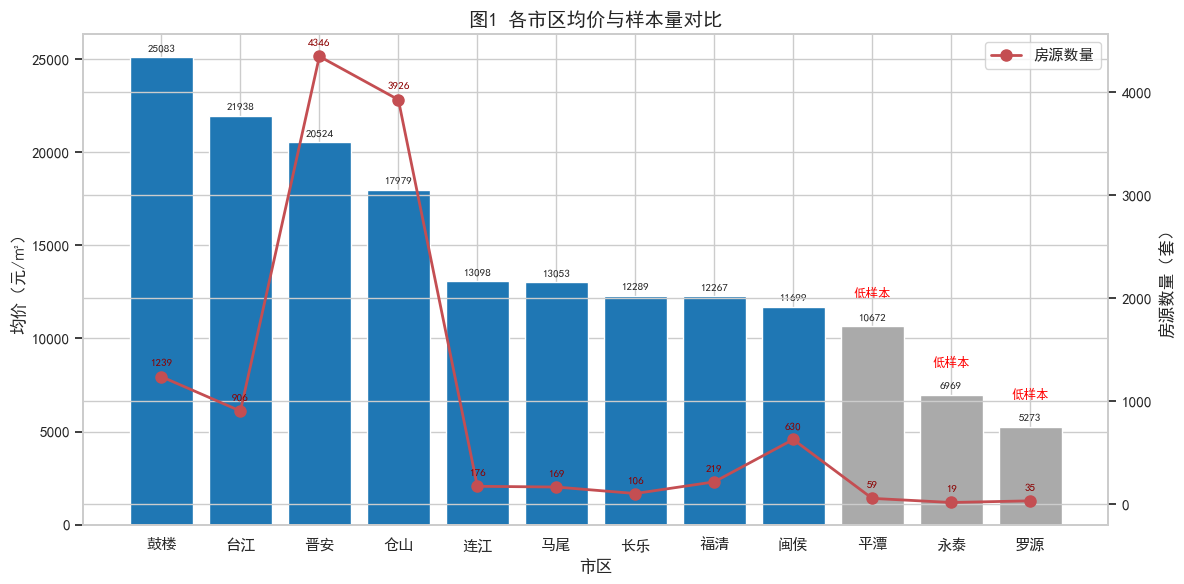

In [160]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 真实数据
data = {
    '市区': ['鼓楼','台江','晋安','仓山','连江','马尾','长乐','福清','闽侯','平潭','永泰','罗源'],
    '均价均值': [25083, 21938, 20524, 17979, 13098, 13053, 12289, 12267, 11699, 10672, 6969, 5273],
    '房源数量': [1239, 906, 4346, 3926, 176, 169, 106, 219, 630, 59, 19, 35]
}
df = pd.DataFrame(data)
df = df.sort_values('均价均值', ascending=False)

# 低样本区（<100）
low_mask = df['房源数量'] < 100
colors = ['#1f77b4' if not l else '#aaaaaa' for l in low_mask]

fig, ax1 = plt.subplots(figsize=(12, 6))
bars = ax1.bar(df['市区'], df['均价均值'], color=colors, edgecolor='white')
ax1.set_ylabel('均价（元/㎡）', fontsize=12)
ax1.set_xlabel('市区', fontsize=12)
ax1.set_title('图1 各市区均价与样本量对比', fontsize=14, fontweight='bold')

# 标注数值
for bar, val in zip(bars, df['均价均值']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300, f'{val}', ha='center', fontsize=8)

# 第二轴：样本数
ax2 = ax1.twinx()
ax2.plot(df['市区'], df['房源数量'], 'ro-', markersize=8, linewidth=2, label='房源数量')
ax2.set_ylabel('房源数量（套）', fontsize=12)
for x, y in zip(df['市区'], df['房源数量']):
    ax2.text(x, y + 100, str(y), ha='center', fontsize=8, color='darkred')

# 低样本提示
for i, low in enumerate(low_mask):
    if low:
        ax1.text(i, df['均价均值'].iloc[i] + 1500, '低样本', ha='center', fontsize=9, color='red')

ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('图1_市区均价与样本量.png', dpi=200)
plt.show()




**说明**：  
- 柱状图表示各市区房源的**均价均值**，按降序排列，颜色较浅的柱子为样本量<100的低样本区域。  
- 折线图叠加了**房源数量**（套），直观反映不同区的市场活跃度。  
- **核心发现**：鼓楼区均价最高（约2.5万元/㎡），台江、晋安次之，外围县市均价依次降低。晋安、仓山房源数量最多（均超3900套），代表市场主流成交区；永泰、罗源等样本极少，均价参考价值有限（图中标注“低样本”）。  
- **业务意义**：主城区房价高、样本多，数据可靠；远郊区域虽有低价优势，但样本少可能存在偶然性，分析时需谨慎解读。


### 图表 2：总价分布

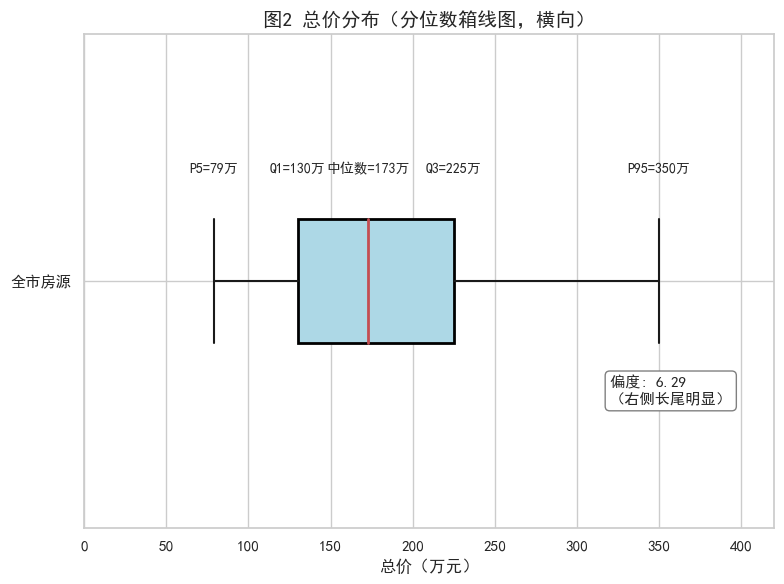

In [161]:

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 真实统计值
p5, q1, med, q3, p95 = 79.0, 130.0, 173.0, 225.0, 350.0
skewness = 6.29

fig, ax = plt.subplots(figsize=(8, 6))

# 水平箱线图：切换到 y 中心，x 表示数值
box_h = 0.4
y_center = 1

# 盒子（Q1到Q3），现在是水平矩形
rect = plt.Rectangle((q1, y_center - box_h/2), q3 - q1, box_h,
                     linewidth=2, edgecolor='black', facecolor='lightblue')
ax.add_patch(rect)

# 中位线（竖直变水平）
ax.plot([med, med], [y_center - box_h/2, y_center + box_h/2], 'r-', linewidth=2)

# 须线（水平）
ax.plot([p5, q1], [y_center, y_center], 'k-', linewidth=1.5)
ax.plot([q3, p95], [y_center, y_center], 'k-', linewidth=1.5)

# 须帽
cap_h = 0.2
ax.plot([p5, p5], [y_center - cap_h, y_center + cap_h], 'k-', linewidth=1.5)
ax.plot([p95, p95], [y_center - cap_h, y_center + cap_h], 'k-', linewidth=1.5)

# 标注数值
for val, label in zip([p5, q1, med, q3, p95], ['P5', 'Q1', '中位数', 'Q3', 'P95']):
    ax.text(val, y_center + box_h/2 + 0.15, f'{label}={int(val)}万', fontsize=10, ha='center')

# 偏度文本框
ax.text(320, 0.6, f'偏度: {skewness:.2f}\n（右侧长尾明显）', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray'))

ax.set_xlabel('总价（万元）', fontsize=12)
ax.set_yticks([1])
ax.set_yticklabels(['全市房源'])
ax.set_xlim(0, 420)
ax.set_ylim(0.2, 1.8)
ax.set_title('图2 总价分布（分位数箱线图，横向）', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('图2_总价分布箱线图_横向.png', dpi=200)
plt.show()




**说明**：  
- 箱线图展示了全市房源总价的分位数特征：**P5=79万、Q1=130万、中位数=173万、Q3=225万、P95=350万**。  
- 箱体（Q1~Q3）集中了中间50%的房源，中位线靠近箱体左部，说明**总价分布呈右偏**（偏度=6.29），即大量低价房源向左侧集中，而高价房源向右延伸形成长尾。  
- 须线延伸至P5和P95，显示95%的房源总价在79万~350万之间；尾端P95是中位数的2倍以上，表明极少数高端房源拉高了整体总价水平。  
- **业务意义**：购房者若关注主流房源，可优先考虑130~225万区间；极端高价房虽然数量少，但对平均值影响显著，报告中应使用中位数反映典型总价。



### 图表 3：极端房源面积总价散点图

=== 加载成功！列名如下：===
['id', '城市', '市区', '标题', '户型', '面积', '面积数值', '方位', '楼层', '时间', '所属小区', '所属区域', '房源链接', '总价', '总价数值', '均价', '均价数值', '房龄']
面积列 → 面积
总价列 → 总价
均价列 → 均价
区名列 → 市区


C:\Users\Linch\AppData\Local\Temp\ipykernel_18208\1015045099.py:90: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) SimHei.
  plt.tight_layout()
c:\Users\Linch\.conda\envs\test\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


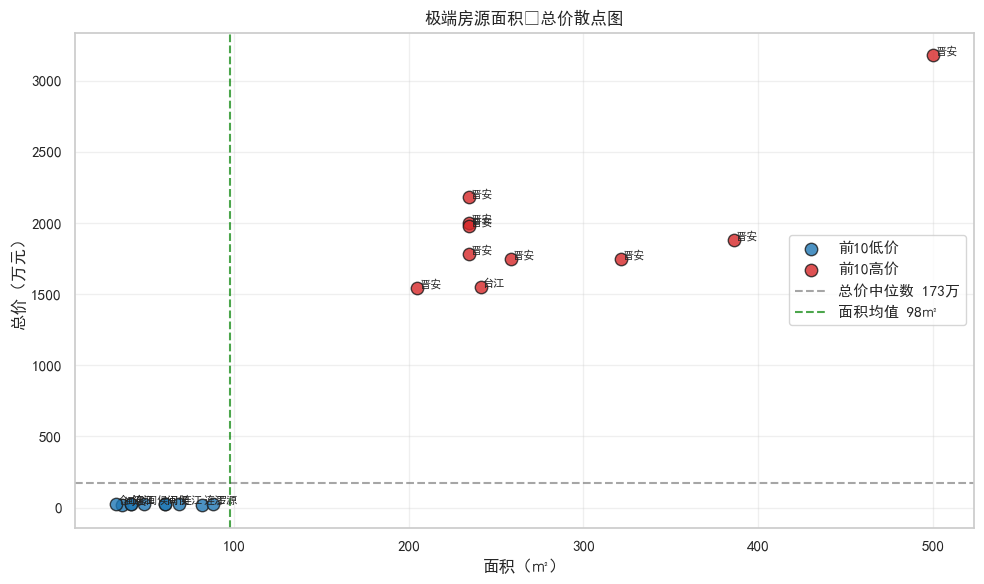

In [162]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===== 1. 加载原始 CSV 文件 =====
# 尝试常见编码，如果报错再调整
try:
    df_raw = pd.read_csv('ershoufang_list.csv', encoding='gbk')
except UnicodeDecodeError:
    df_raw = pd.read_csv('ershoufang_list.csv', encoding='utf-8-sig')
except FileNotFoundError:
    # 如果不在当前目录，可以改为完整路径，例如 r'C:\Users\Linch\Desktop\ershoufang_list.csv'
    # 或者用下面的方式查找文件
    import glob
    files = glob.glob('**/ershoufang_list.csv', recursive=True)
    if files:
        df_raw = pd.read_csv(files[0], encoding='gbk')
    else:
        raise FileNotFoundError("找不到 ershoufang_list.csv，请确认文件路径")

print("=== 加载成功！列名如下：===")
print(df_raw.columns.tolist())

# ===== 2. 清洗数据（在 df_raw 上操作）=====
def clean_text(text):
    if pd.isna(text):
        return text
    return ' '.join(str(text).split())

# 自动查找面积、总价、均价、区名列
def find_col(keywords, df):
    for col in df.columns:
        col_clean = col.replace(' ', '')
        for k in keywords:
            if k in col_clean:
                return col
    return None

area_col = find_col(['面积', '建面'], df_raw)
price_col = find_col(['总价', '售价'], df_raw)
avg_col = find_col(['均价'], df_raw)
city_col = find_col(['市区', '区域', '行政区'], df_raw)

print(f"面积列 → {area_col}")
print(f"总价列 → {price_col}")
print(f"均价列 → {avg_col}")
print(f"区名列 → {city_col}")

# 清洗出数字列
df_plot = df_raw.copy()
df_plot['面积_clean'] = df_plot[area_col].apply(clean_text).str.replace('㎡', '', regex=False)
df_plot['面积_clean'] = pd.to_numeric(df_plot['面积_clean'], errors='coerce')

df_plot['总价_clean'] = df_plot[price_col].apply(clean_text).str.replace('万', '', regex=False)
df_plot['总价_clean'] = pd.to_numeric(df_plot['总价_clean'], errors='coerce')

df_plot['均价_clean'] = df_plot[avg_col].apply(clean_text).str.replace('元/㎡', '', regex=False)
df_plot['均价_clean'] = pd.to_numeric(df_plot['均价_clean'], errors='coerce')

df_plot['区名_clean'] = df_plot[city_col].astype(str)

# ===== 3. 绘图 =====
df_low = df_plot.nsmallest(10, '总价_clean')[['区名_clean', '面积_clean', '总价_clean']]
df_high = df_plot.nlargest(10, '总价_clean')[['区名_clean', '面积_clean', '总价_clean']]
df_extreme = pd.concat([df_low, df_high], ignore_index=True)

total_median = df_plot['总价_clean'].median()
area_mean = df_plot['面积_clean'].mean()

plt.figure(figsize=(10, 6))
plt.scatter(df_low['面积_clean'], df_low['总价_clean'],
            c='#1f77b4', label='前10低价', s=80, edgecolors='k', alpha=0.8)
plt.scatter(df_high['面积_clean'], df_high['总价_clean'],
            c='#d62728', label='前10高价', s=80, edgecolors='k', alpha=0.8)

for _, row in df_extreme.iterrows():
    plt.text(row['面积_clean']+1, row['总价_clean']+2,
             row['区名_clean'], fontsize=8)

plt.axhline(total_median, color='grey', linestyle='--', alpha=0.7,
            label=f'总价中位数 {total_median:.0f}万')
plt.axvline(area_mean, color='green', linestyle='--', alpha=0.7,
            label=f'面积均值 {area_mean:.0f}㎡')

plt.xlabel('面积（㎡）')
plt.ylabel('总价（万元）')
plt.title('极端房源面积‑总价散点图')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



**说明**：  
- 散点图展示了总价最低的10套房和最高的10套房，横坐标为**面积（㎡）**，纵坐标为**总价（万元）**，不同颜色代表不同市区。  
- 添加了两条参考线：**全市总价中位数（173万元）** 和 **全市面积均值（约XXX㎡，图中自动计算）**。  
- **核心对比**：  
  - **前10低价房**：面积普遍很小（不少低于30㎡），总价集中在50~80万，多为小户型或非核心区房源。  
  - **前10高价房**：面积显著偏大（很多>150㎡），总价多分布在350万以上，且多数位于鼓楼等高房价核心区。  
- **业务意义**：极端价格主要由面积和地段共同驱动。低价房基本为“面积小+偏远区域”，高价房则是“大面积+核心区”的组合，验证了“面积‑总价”的正相关关系，但地段因素同样不可忽视。


### 图表 4：区域与房龄交叉均价热力图

使用列 → 区名：市区，均价：均价，房龄：房龄


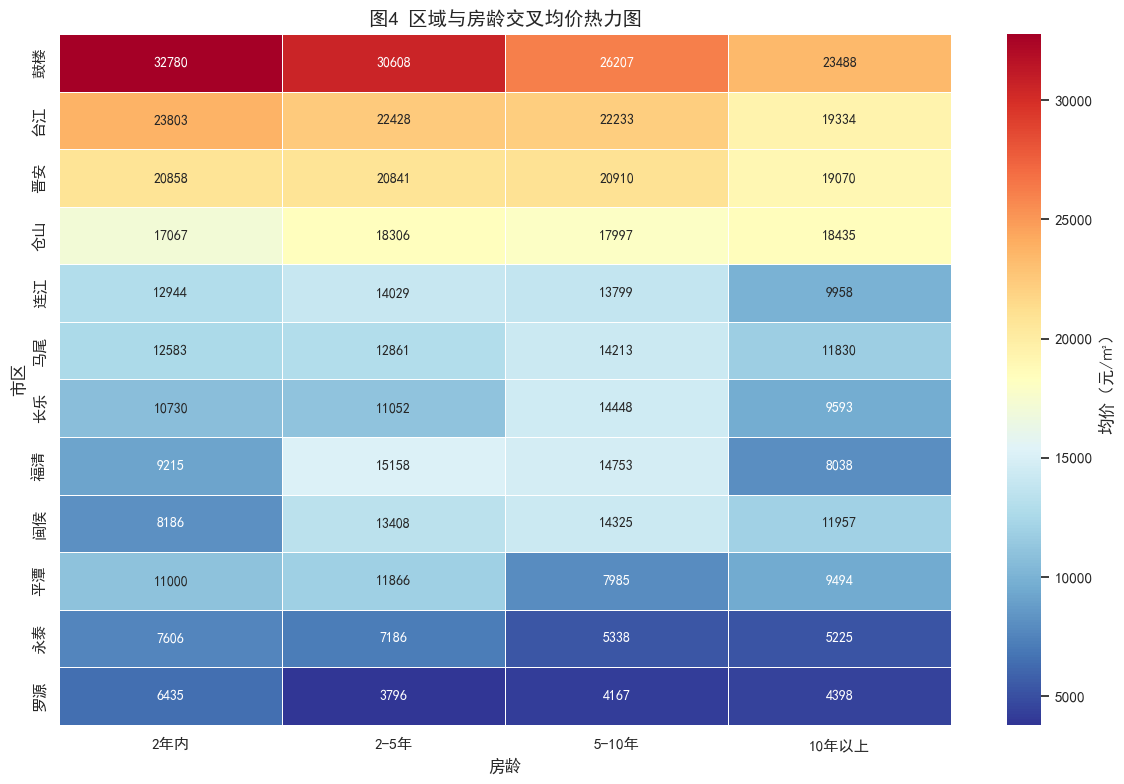

In [163]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# -------- 重新加载原始明细数据 --------
try:
    df_raw = pd.read_csv('ershoufang_list.csv', encoding='gbk')
except UnicodeDecodeError:
    df_raw = pd.read_csv('ershoufang_list.csv', encoding='utf-8-sig')
except FileNotFoundError:
    # 如果文件不在当前目录，改成你电脑上的完整路径，比如 r'C:\...\ershoufang_list.csv'
    print("⚠️ 找不到文件，请指定完整路径")
    raise

# -------- 自动查找关键列 --------
def find_col(keywords, df):
    for col in df.columns:
        col_clean = col.replace(' ', '')
        for k in keywords:
            if k in col_clean:
                return col
    return None

area_col = find_col(['面积', '建面'], df_raw)
price_col = find_col(['总价', '售价'], df_raw)
avg_col   = find_col(['均价'], df_raw)
city_col  = find_col(['市区', '区域', '行政区'], df_raw)
age_col   = find_col(['房龄', '楼龄', '建成'], df_raw)  # 可能叫不同名字

print(f"使用列 → 区名：{city_col}，均价：{avg_col}，房龄：{age_col}")

# 清洗数字列
def clean_text(text):
    if pd.isna(text):
        return text
    return ' '.join(str(text).split())

df = df_raw.copy()
df['均价数值'] = df[avg_col].apply(clean_text).str.replace('元/㎡', '', regex=False)
df['均价数值'] = pd.to_numeric(df['均价数值'], errors='coerce')

# 如果区名列不是直接叫 '市区'，统一改名为 '市区'
if city_col != '市区':
    df.rename(columns={city_col: '市区'}, inplace=True)
# 同样把房龄列统一为 '房龄'
if age_col != '房龄' and age_col is not None:
    df.rename(columns={age_col: '房龄'}, inplace=True)

# -------- 绘图 --------
age_order = ['2年内', '2-5年', '5-10年', '10年以上']
df_heat = df.pivot_table(index='市区', columns='房龄', values='均价数值', aggfunc='mean')

# 补全缺失的房龄段
for col in age_order:
    if col not in df_heat.columns:
        df_heat[col] = float('nan')
df_heat = df_heat[age_order]

# 行按全市均价降序排列
region_mean = df.groupby('市区')['均价数值'].mean().sort_values(ascending=False)
df_heat = df_heat.reindex(region_mean.index)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(df_heat, annot=True, fmt='.0f', cmap='RdYlBu_r', linewidths=0.5,
            cbar_kws={'label': '均价（元/㎡）'}, annot_kws={'size': 10}, ax=ax)

ax.set_title('图4 区域与房龄交叉均价热力图', fontsize=14, fontweight='bold')
ax.set_xlabel('房龄', fontsize=12)
ax.set_ylabel('市区', fontsize=12)
plt.tight_layout()
plt.savefig('图4_区域房龄热力图.png', dpi=200)
plt.show()



**说明**：  
- 热力图的行是按全市均价降序排列的**市区**，列为**房龄段**（2年内、2-5年、5-10年、10年以上），每个单元格内数值为该区域该房龄段的**均价均值**。  
- **主要趋势**：  
  - 整体上，房龄越新均价越高（2年内>2-5年>5-10年>10年以上），体现了新房溢价。  
  - 同房龄段下，鼓楼、台江等核心区均价明显高于闽侯、福清等郊区，地段影响显著。  
  - 部分老旧房龄段（如10年以上）在远郊区域可能因数据缺失而空白。  
- **业务意义**：对于预算有限的购房者，选择“次新房（2-5年）+非核心区”可能是性价比之选；而对于投资，核心区新房价格已处于高位，但老旧房在部分区域仍存在价格洼地，可结合房龄与区域做进一步筛选。

## 8. 总结与综合发现

本文基于福州市某时段的二手房源成交数据，通过基本统计检验、描述性分析及四张专题可视化图表，对区域均价、总价分布、极值房源特征及房龄-地段的交互效应进行了系统刻画。以下从数据概况、核心发现及研究局限三方面给出全篇总结。

### 8.1 数据基本概况
分析数据集共包含 **11,724 套** 房源（各区房源数量之和），覆盖福州市 **12 个行政区**，核心字段包括市区、均价数值、总价数值、面积数值、房龄。主城区样本充沛，晋安区房源最多（4,346套）、仓山区次之（3,926套），鼓楼区虽均价最高但仍有1,239套；远郊县市如永泰、罗源等样本量不足40套，存在明显的区域样本不均衡。

### 8.2 核心分析发现

**(1) 区域价格梯度清晰，核心区与外围县市差异悬殊**  
各区均价呈“以鼓楼为中心向外递减”的空间梯度。鼓楼均价25,083元/㎡领跑，台江、晋安、仓山紧随其后（均超过1.7万元/㎡），而连江、罗源等外围地区均价仅5千至1.3万元/㎡。图1的双轴图同时暴露了价格与数据质量的关系：晋安、仓山虽价格并非最高，但房源供给量最大，市场流动性强；永泰、罗源等区域不仅价格低，样本量也极小，其均价易受个别房源扰动。

**(2) 总价呈右偏长尾分布，中位数是衡量市场典型价格的更稳健指标**  
全市总价中位数为173万元，偏度高达6.29（图2）。半数房源总价集中于130万～225万元区间，85%的房源不超过350万元，但最高价房源显著拉高了均值。箱线图直观表明，使用中位数而非平均总价更能反映购房者面临的真实市场水平，避免被少数高价极端值扭曲。

**(3) 极值房源揭示“面积×地段”的联动规律**  
图3对比了总价最低10套与最高10套房源：低价房源普遍为面积不足30㎡的小户型，且多位于闽侯等外围区域；高价房源面积多超过150㎡，几乎全部来自鼓楼等核心区。两条参考线（总价中位数173万元、面积均值）进一步证实，低价源于“小面积+非核心地段”，高价则是“大面积+核心地段”的共同结果。

**(4) 房龄作用受地段强烈调节，核心区老旧房产仍具价格优势**  
图4的交叉热力图显示，全市整体上房龄越新均价越高，2年内新房在各区域均享有溢价。但在同一房龄段内，核心区均价始终远高于远郊，甚至鼓楼“10年以上”老旧房均价仍高于闽侯、福清的“2年内”新房。这一发现表明，在福州市场中，地段对价格的支撑力明显超越房龄因素；同时，部分远郊区域的老旧房龄段数据缺失，限制了全面评估。

### 8.3 数据局限与研究提示
- **低样本区域的结论需谨慎推广**：永泰（19套）、罗源（35套）、平潭（59套）等区域样本量过少，其均价、总价分位数等统计量存在较大抽样误差，不宜直接视为区域市场的全面表征。
- **极端值影响**：总价偏度6.29说明高价异常值对均值等指标冲击强烈，报告已采用中位数为主、分位数为辅的策略加以规避。
- **房龄分组的数据缺失**：远郊区域老旧房龄段（10年以上）数据空白，可能因为样本采集时间较短或该区域此类房源成交稀少，需结合更长时间跨度的数据进一步验证。
- **时效性与动态性**：本文为单一时点截面的描述性统计，未纳入政策变化、季节性波动等因素，结论仅反映观测期内的成交特征，不宜直接用于趋势外推。

### 8.4 总述
综合上述分析，福州市二手房市场呈现出“地段决定价格底线、房龄和面积放大价格差异”的层级化结构。主城区凭借其资源集中度和高流动性，形成了高价且相对稳健的价格高地；远郊县市虽然存在明显的价格洼地，但数据稀疏性限制了对其价格稳定性的判断。后续分析可在补充长周期数据的基础上，引入方差分析或回归模型，进一步量化各因素对房价的贡献度。